In [58]:
import warnings

import decoupler as dc
import pertpy as pt
import scanpy as sc

warnings.filterwarnings("ignore")

In [59]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [60]:
adata

AnnData object with n_obs × n_vars = 980474 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
pdata = dc.pp.pseudobulk(adata, sample_col="sample_id", groups_col="cell_type", layer="counts", mode="sum")
dc.pp.filter_samples(pdata, inplace=True)
pdata

AnnData object with n_obs × n_vars = 528 × 5101
    obs: 'sample_id', 'cell_type', 'run', 'cell_class', 'age', 'sex', 'genotype', 'condition', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'psbulk_props'

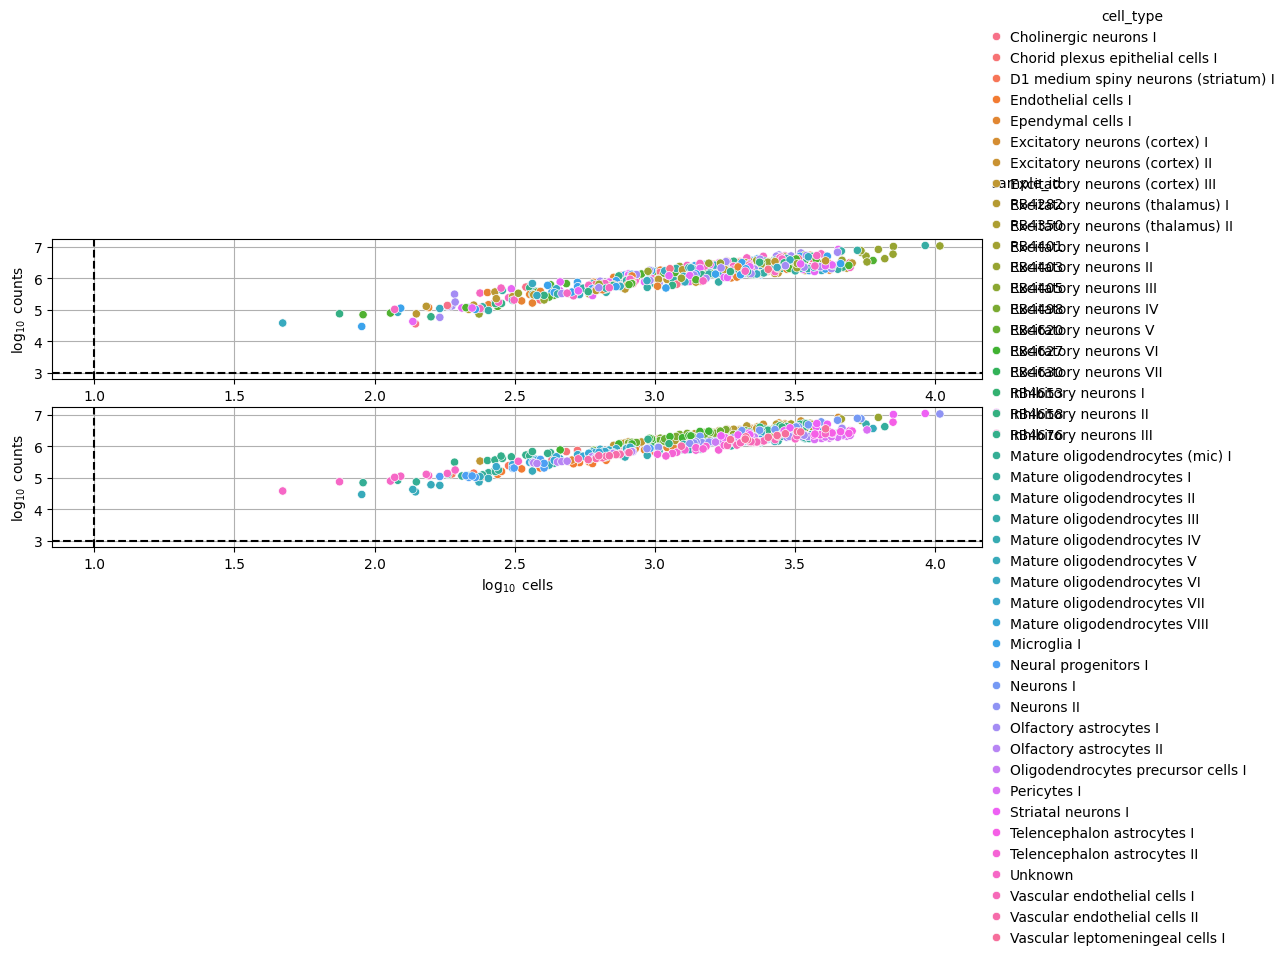

In [5]:
dc.pl.filter_samples(pdata, groupby=["sample_id", "cell_type"], figsize=(12, 4))

In [6]:
pdata.layers["counts"] = pdata.X.copy()

sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.pp.pca(pdata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [7]:
# Return raw counts to X
dc.pp.swap_layer(pdata, "counts", inplace=True)

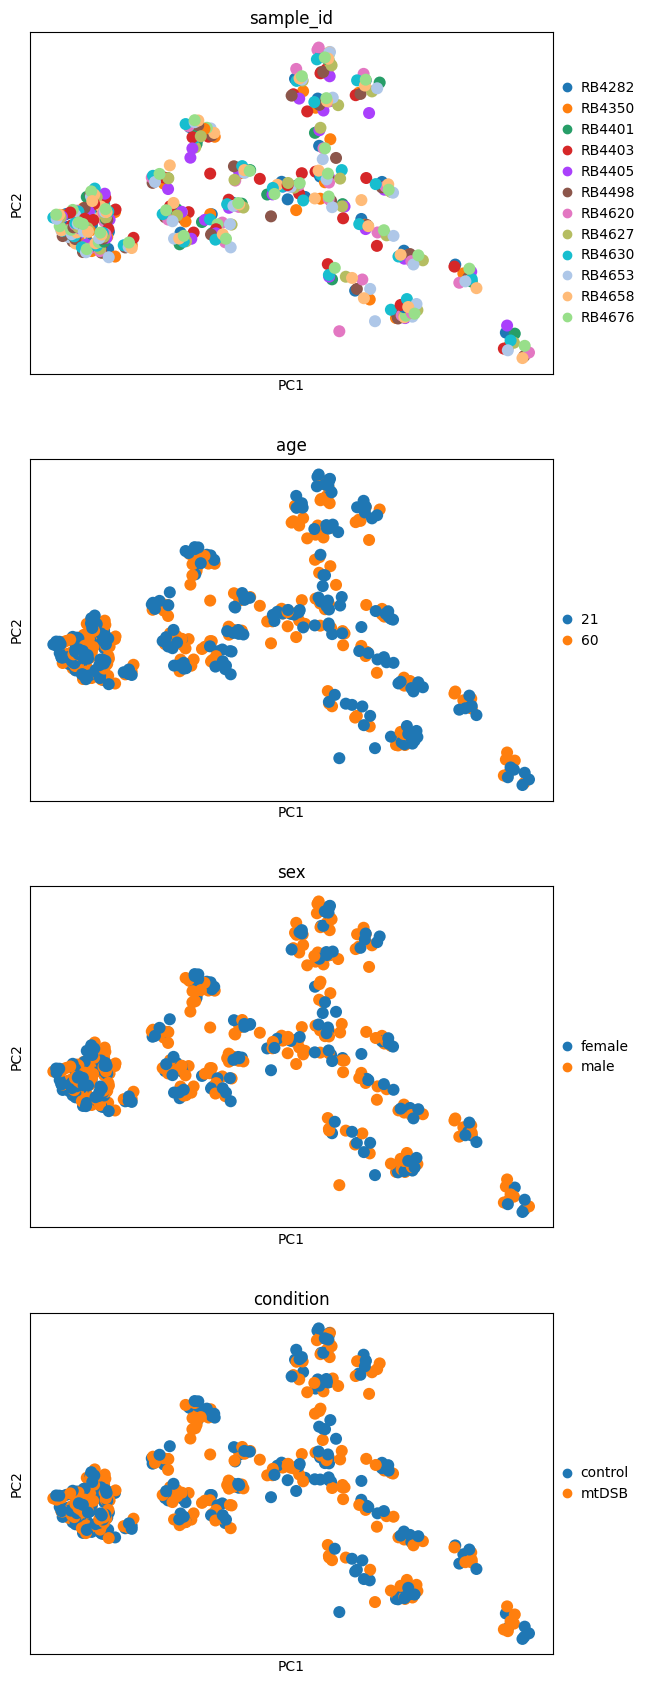

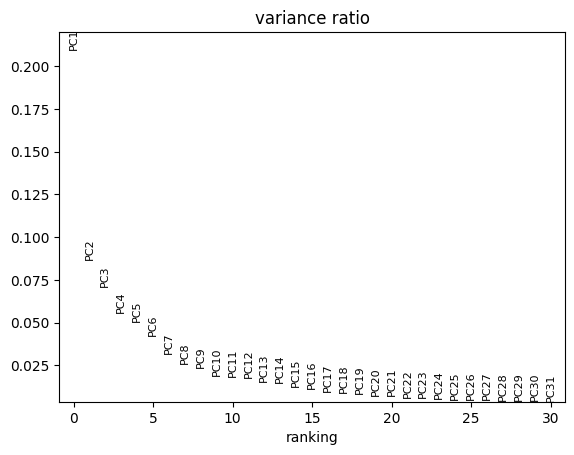

In [8]:
sc.pl.pca(pdata, color=["sample_id", "age", "sex", "condition"], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

In [9]:
pdata_subset = pdata.copy()
pdata_subset.obs = pdata.obs[["sample_id", "age", "sex", "condition"]]

dc.tl.rankby_obsm(
    pdata_subset,
    key="X_pca",
    uns_key="pca_anova",
)

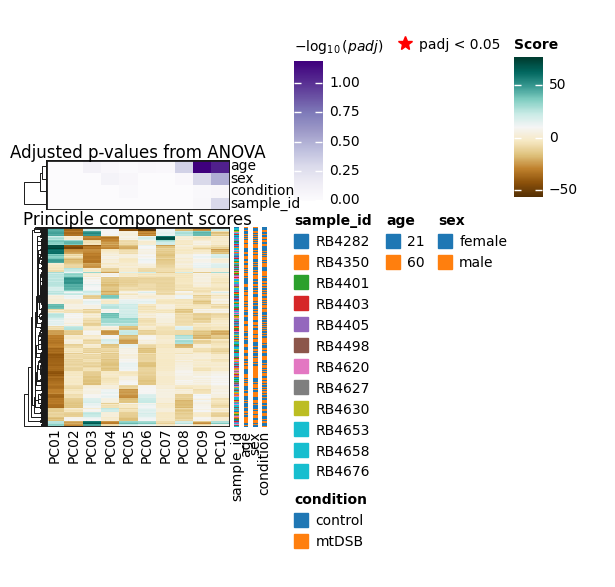

In [10]:
dc.pl.obsm(
    pdata_subset,
    key="pca_anova",
    names=["sample_id", "age", "sex", "condition"],
    titles=["Principle component scores", "Adjusted p-values from ANOVA"],
    cmap_obs={},
)

In [18]:
pdata.obs

,sample_id,cell_type,run,cell_class,age,sex,genotype,condition,psbulk_cells,psbulk_counts,size_factors,replaceable
RB4282_Cholinergic neurons I,RB4282,Cholinergic neurons I,output-XETG00045__0060539__RB4282__20250917__1...,Cholinergic neurons,60,male,PlptTA,control,1697.0,1509843.0,1.345700,True
RB4350_Cholinergic neurons I,RB4350,Cholinergic neurons I,output-XETG00045__0060539__RB4350__20250917__1...,Cholinergic neurons,60,male,PlptTA,control,1000.0,863844.0,0.790534,True
RB4401_Cholinergic neurons I,RB4401,Cholinergic neurons I,output-XETG00045__0060539__RB4401__20250917__1...,Cholinergic neurons,60,female,PlptTA:mtPst1,mtDSB,1283.0,1029367.0,0.929777,True
RB4403_Cholinergic neurons I,RB4403,Cholinergic neurons I,output-XETG00045__0060539__RB4403__20250917__1...,Cholinergic neurons,60,male,PlptTA:mtPst1,mtDSB,1621.0,1513782.0,1.348303,True
RB4405_Cholinergic neurons I,RB4405,Cholinergic neurons I,output-XETG00045__0060539__RB4405__20250917__1...,Cholinergic neurons,60,male,PlptTA:mtPst1,mtDSB,742.0,637292.0,0.579542,True
...,...,...,...,...,...,...,...,...,...,...,...,...
RB4627_Vascular leptomeningeal cells I,RB4627,Vascular leptomeningeal cells I,output-XETG00045__0060541__RB4627__20250917__1...,Vascular leptomeningeal cells,21,male,PlptTA:mtPst1,mtDSB,2735.0,2224655.0,1.753793,True
RB4630_Vascular leptomeningeal cells I,RB4630,Vascular leptomeningeal cells I,output-XETG00045__0060541__RB4630__20250917__1...,Vascular leptomeningeal cells,21,male,PlptTA:mtPst1,mtDSB,2116.0,2007494.0,1.631754,True
RB4653_Vascular leptomeningeal cells I,RB4653,Vascular leptomeningeal cells I,output-XETG00045__0060541__RB4653__20250917__1...,Vascular leptomeningeal cells,21,female,PlptTA:mtPst1,mtDSB,2928.0,2524375.0,2.009237,True
RB4658_Vascular leptomeningeal cells I,RB4658,Vascular leptomeningeal cells I,output-XETG00045__0060541__RB4658__20250917__1...,Vascular leptomeningeal cells,21,female,PlptTA,control,3319.0,2871227.0,2.232198,True


In [46]:
pds2 = pt.tl.PyDESeq2(adata=pdata, design="~condition")


In [47]:
pds2.fit()

Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.27 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.30 seconds.

Fitting LFCs...
... done in 0.22 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 577 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.05 seconds.



In [48]:
res_df = pds2.test_contrasts(pds2.contrast(column="condition", baseline="control", group_to_compare="mtDSB"))


Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9       1.113354        0.210315  0.170463  1.233787  0.217282  0.998951
Adcy1     1079.334947        0.133358  0.136231  0.978913  0.327623  0.998951
Atp6v0d2     1.021316        0.644108  0.208844  3.084153  0.002041  0.105260
Dnm1l      904.089487        0.028005  0.051228  0.546683  0.584596  0.998951
S100b      251.247366        0.015638  0.081724  0.191346  0.848254  0.998951
...               ...             ...       ...       ...       ...       ...
Prf1         0.669458       -0.055480  0.270132 -0.205380  0.837276  0.998951
Emsy       194.548251       -0.009387  0.027941 -0.335942  0.736915  0.998951
Icam1       33.310323        0.224413  0.229268  0.978825  0.327666  0.998951
Gldc        57.444811        0.039002  0.148804  0.262107  0.793239  0.998951
Atp4a        2.886256       -0.102492  0.134462 -0.762236  0.445919  0.998951



Running Wald tests...
... done in 0.14 seconds.



In [49]:
res_df.head(10)


,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,Prl,36.851374,-3.877435,0.274706,-14.114877,3.075533e-45,1.568829e-41,None
1,Gh,116.858842,-3.086793,0.274306,-11.253097,2.236009e-29,5.702940e-26,None
2,Cst7,9.403972,2.584303,0.232019,11.138315,8.164921e-29,1.388309e-25,None
3,Cga,9.494752,-2.699440,0.287803,-9.379461,6.631074e-21,8.456277e-18,None
4,Bglap2,4.465547,-1.708205,0.185476,-9.209862,3.265439e-20,3.331401e-17,None
5,Pomc,22.403873,-1.035433,0.132380,-7.821700,5.211452e-15,4.430603e-12,None
6,Tshb,2.828924,-2.005052,0.258727,-7.749679,9.212539e-15,6.353577e-12,None
7,Klk6,3.603971,-2.154396,0.278356,-7.739709,9.964442e-15,6.353577e-12,None
8,Myh4,5.265974,-1.582868,0.209032,-7.572381,3.664453e-14,2.076931e-11,None
9,Myh1,4.508571,-1.380713,0.184333,-7.490338,6.869629e-14,3.504198e-11,None


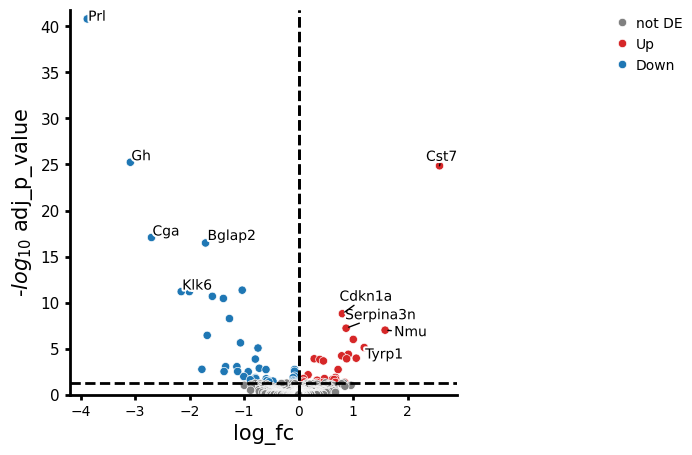

In [50]:
pds2.plot_volcano(res_df, log2fc_thresh=0)


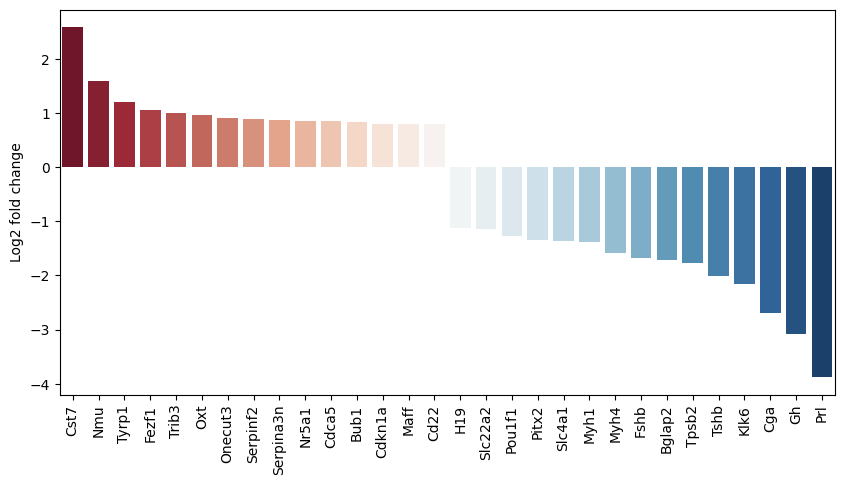

In [51]:
pds2.plot_fold_change(res_df, n_top_vars=15)


Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.28 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.30 seconds.

Fitting LFCs...
... done in 0.23 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 577 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.05 seconds.

Running Wald tests...
... done in 0.14 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9       1.113354        0.210315  0.170463  1.233787  0.217282  0.998951
Adcy1     1079.334947        0.133358  0.136231  0.978913  0.327623  0.998951
Atp6v0d2     1.021316        0.644108  0.208844  3.084153  0.002041  0.105260
Dnm1l      904.089487        0.028005  0.051228  0.546683  0.584596  0.998951
S100b      251.247366        0.015638  0.081724  0.191346  0.848254  0.998951
...               ...             ...       ...       ...       ...       ...
Prf1         0.669458       -0.055480  0.270132 -0.205380  0.837276  0.998951
Emsy       194.548251       -0.009387  0.027941 -0.335942  0.736915  0.998951
Icam1       33.310323        0.224413  0.229268  0.978825  0.327666  0.998951
Gldc        57.444811        0.039002  0.148804  0.262107  0.793239  0.998951
Atp4a        2.886256       -0.102492  0.134462 -0.762236  0.445919  0.998951



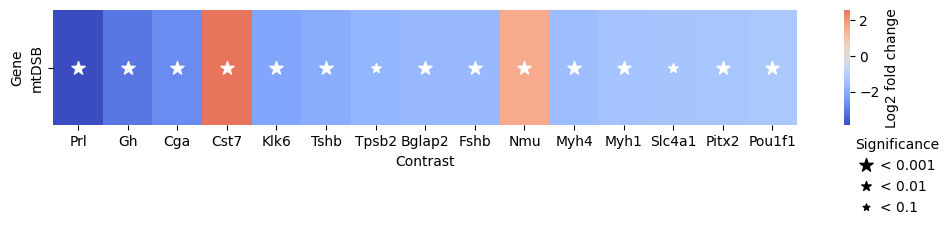

In [52]:
res_df = pds2.compare_groups(pdata, column="condition", baseline="control", groups_to_compare=["mtDSB"])
edgr.plot_multicomparison_fc(res_df, figsize=(12, 1.5))

## with age as well

In [53]:
pds = pt.tl.PyDESeq2(adata=pdata, design="~ age + condition")

In [54]:
pds2.fit()


Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.27 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.30 seconds.

Fitting LFCs...
... done in 0.22 seconds.

Calculating cook's distance...
... done in 0.09 seconds.

Replacing 577 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.05 seconds.



In [56]:
res_df = pds2.test_contrasts(pds2.contrast(column="condition", baseline="control", group_to_compare="mtDSB"))

Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Tnfsf9       1.113354        0.210315  0.170463  1.233787  0.217282  0.998951
Adcy1     1079.334947        0.133358  0.136231  0.978913  0.327623  0.998951
Atp6v0d2     1.021316        0.644108  0.208844  3.084153  0.002041  0.105260
Dnm1l      904.089487        0.028005  0.051228  0.546683  0.584596  0.998951
S100b      251.247366        0.015638  0.081724  0.191346  0.848254  0.998951
...               ...             ...       ...       ...       ...       ...
Prf1         0.669458       -0.055480  0.270132 -0.205380  0.837276  0.998951
Emsy       194.548251       -0.009387  0.027941 -0.335942  0.736915  0.998951
Icam1       33.310323        0.224413  0.229268  0.978825  0.327666  0.998951
Gldc        57.444811        0.039002  0.148804  0.262107  0.793239  0.998951
Atp4a        2.886256       -0.102492  0.134462 -0.762236  0.445919  0.998951



Running Wald tests...
... done in 0.14 seconds.



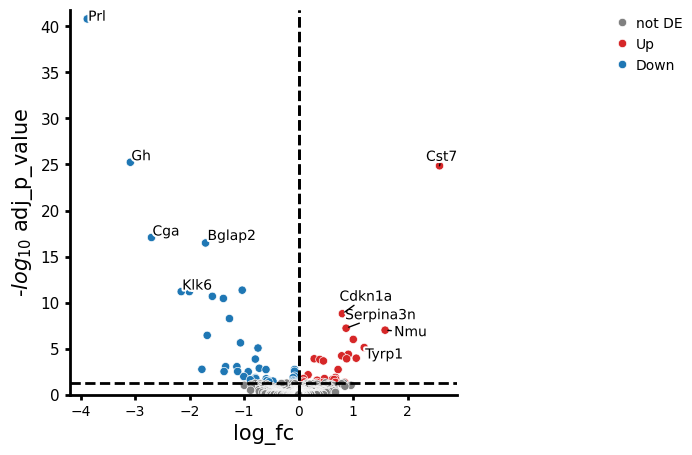

In [57]:
pds2.plot_volcano(res_df, log2fc_thresh=0)
